# Notebook 1: Introduction to Machine Learning & Linear Regression

Ghana AI Talent Accelerator - Machine Learning Foundations

Speedykom Group GmbH

<a href="https://colab.research.google.com/github/Speedykom/GIZ_GhanaAI_Training_Materials/blob/main/05-machine-learning/intro_ML1.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 1. What is Machine Learning?

### The Fundamental Shift

In traditional programming, you write rules that tell a computer exactly
what to do:

``` python
# Traditional programming: YOU write the rules
if temperature > 30:
    print("Hot day!")
elif temperature < 20:
    print("Cool day!")
else:
    print("Pleasant day!")
```

In **Machine Learning**, you show the computer examples of data and let
it discover the patterns and rules itself:

``` python
# Machine learning: The COMPUTER discovers the rules
# You provide: (temperature, "hot"), (temperature, "cool"), (temperature, "pleasant")
# Model learns: temperature > 30 → "hot", temperature < 20 → "cool", etc.
```

### Definition: Machine Learning in One Sentence

**Machine Learning is the science of getting computers to act without
being explicitly programmed**—they learn patterns from data instead.

### The Three Pillars of Learning

Machine learning has three main branches:

| Type | What It Does | Example |
|:-----------------------|:-----------------------|:-----------------------|
| **Supervised Learning** | Learn from labeled examples | Predict house prices |
| **Unsupervised Learning** | Find hidden patterns in unlabeled data | Customer segmentation |
| **Reinforcement Learning** | Learn through trial and error | Self-driving cars |

### Two Key Supervised Learning Tasks

Within supervised learning, there are two main problem types:

**1. Regression**: Predict continuous values (numbers)

-   House price: ₵250,000, ₵420,000, ₵185,000
-   Temperature: 25.3°C, 31.7°C, 18.2°C
-   Sales: 1,250 units, 3,400 units, 890 units

**2. Classification**: Predict categories (labels)

-   Email: spam vs. not spam
-   Image: cat vs. dog vs. bird
-   Medical test: positive vs. negative

------------------------------------------------------------------------

# 2. The Math Foundation: Building Intuition

Before we dive into complex ML algorithms, let’s build intuition with
something familiar: **temperature conversion**.

### The Problem: Celsius to Fahrenheit

We know these two facts:

-   **0°C** (freezing point of water) = **32°F**
-   **100°C** (boiling point of water) = **212°F**

### Visualizing the Data

Let’s plot these two points and see what pattern emerges:

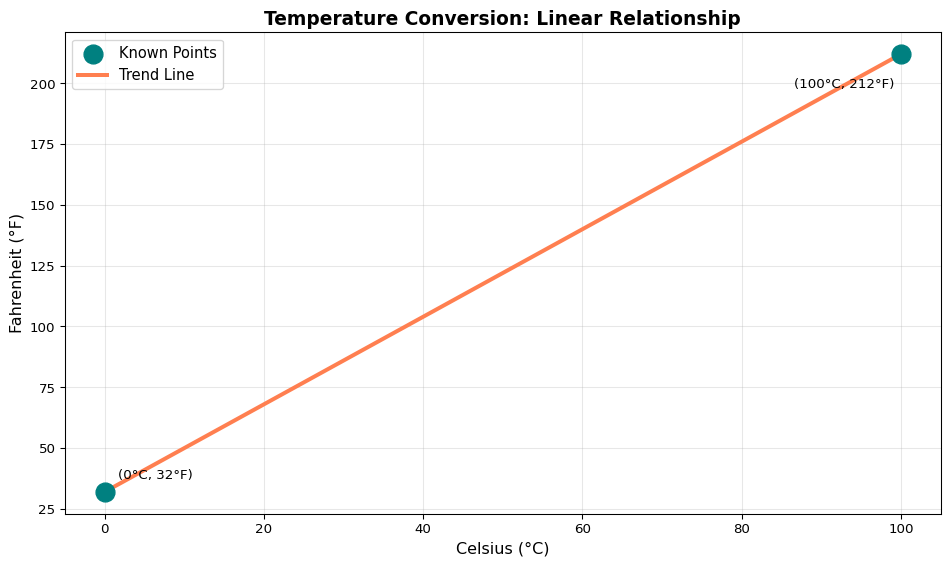

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Known data points
celsius = np.array([0, 100])
fahrenheit = np.array([32, 212])

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the two points
ax.scatter(celsius, fahrenheit, color='teal', s=200, zorder=5, label='Known Points')

# Draw the line connecting them
ax.plot(celsius, fahrenheit, color='coral', linewidth=3, label='Trend Line')

# Add labels
ax.set_xlabel('Celsius (°C)', fontsize=12)
ax.set_ylabel('Fahrenheit (°F)', fontsize=12)
ax.set_title('Temperature Conversion: Linear Relationship', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add value annotations
ax.annotate(f'({celsius[0]}°C, {fahrenheit[0]}°F)', xy=(celsius[0], fahrenheit[0]), 
            xytext=(10, 10), textcoords='offset points', fontsize=10)
ax.annotate(f'({celsius[1]}°C, {fahrenheit[1]}°F)', xy=(celsius[1], fahrenheit[1]), 
            xytext=(-80, -25), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

The key insight: **the data points form a straight line**. This is the
foundation of linear regression.

### Deriving the Formula

A straight line has the formula:

$$y = mx + c$$

Where:

-   $y$ = what we predict (Fahrenheit)
-   $x$ = what we know (Celsius)
-   $m$ = slope (how fast the line rises)
-   $c$ = y-intercept (where the line starts)

**Step 1: Calculate the slope ($m$)**

$$m = \frac{\text{change in } y}{\text{change in } x} = \frac{212 - 32}{100 - 0} = \frac{180}{100} = 1.8$$

**Step 2: Find the y-intercept ($c$)**

We know that when $x = 0$, $y = 32$. So:

$$32 = 1.8 \times 0 + c$$ $$32 = c$$

**Step 3: Write the complete formula**

$$F = 1.8 \times C + 32$$

Or using math notation:

$$\hat{y} = b + wx$$

Where:

-   $\hat{y}$ = predicted value (Fahrenheit)
-   $b$ = bias (intercept - baseline value)
-   $w$ = weight (coefficient - slope)
-   $x$ = input feature (Celsius)

### Testing Our Formula

Let’s verify with a temperature not in our training data:

In [2]:
# Test with 50°C (not in our original data)
celsius_test = 50
fahrenheit_test = 1.8 * celsius_test + 32

print(f"Input: {celsius_test}°C")
print(f"Prediction: {fahrenheit_test:.1f}°F")

# Verify with Python's built-in (as a sanity check)
# The formula is correct: 50°C = 122°F
print(f"\n✅ Verification: 50°C should be 122°F")

Input: 50°C
Prediction: 122.0°F

✅ Verification: 50°C should be 122°F

> **The Key Insight**
>
> We just did **machine learning manually**! We:
>
> 1.  Collected data (two temperature points)
> 2.  Observed the pattern (linear relationship)
> 3.  Derived a formula (F = 1.8 × C + 32)
> 4.  Used the formula to predict new values
>
> Machine learning algorithms do the same thing automatically—with much
> more data!

------------------------------------------------------------------------

# 3. Connecting to Machine Learning Notation

Now that we understand the concept, let’s translate to ML terminology:

| Math Notation | ML Notation              | Meaning            |
|:--------------|:-------------------------|:-------------------|
| $y$           | $\hat{y}$ (y_hat)        | Predicted value    |
| $c$           | $b$ (bias)               | Baseline/intercept |
| $m$           | $w$ (weight/coefficient) | Coefficient/slope  |
| $x$           | $x$                      | Input feature      |

### The ML Formula

In machine learning, we write:

$$\hat{y} = b + wx$$

Where:

-   $\hat{y}$ = predicted value (with “hat” to indicate it’s a
    prediction)
-   $b$ = bias (intercept - baseline value when all features are zero)
-   $w$ = weight (coefficient - how much the feature affects the
    prediction)
-   $x$ = input feature

### Why This Notation Matters

When you see $\hat{y}$, you immediately know: **this is a prediction,
not the actual value**.

When you see $w$ and $b$, you know: **these are parameters the model
learns from data**.

> **Common Confusion: $\hat{y}$ vs. $y$**
>
> -   $y$ (without hat) = actual/true value from the data
> -   $\hat{y}$ (with hat) = predicted value from the model
>
> The difference between them is the **error**:
> $\text{error} = \hat{y} - y$
>
> Machine learning tries to minimize this error across all data points.

------------------------------------------------------------------------

# 4. House Price Prediction: Our First ML Model

Let’s apply what we’ve learned to a real problem: **predicting house
prices in Ghana**.

### The Dataset

We’ll use a synthetic dataset representing Ghanaian houses with one
feature: **size (square meters)**.

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Note: We use random seeds to ensure reproducible results.
# This way, every time you run this code, you'll get the same random numbers.
# The number 42 is commonly used as a playful reference to "The Hitchhiker's Guide to the Galaxy"
# (it's the "Answer to the Ultimate Question of Life, the Universe, and Everything").
# You can use any number - try changing 42 to 67 or any other number!

# Generate synthetic Ghana housing data
size_sqm = np.random.randint(80, 400, 100)

# Price formula: 200 GHS per sqm + 50,000 GHS base + random noise
price_ghs = size_sqm * 200 + 50000 + np.random.normal(0, 15000, 100)

# Create DataFrame
df_houses = pd.DataFrame({
    'size_sqm': size_sqm,
    'price_ghs': price_ghs
})

print("Synthetic Ghana housing dataset:")
print(df_houses.head(10))

print(f"\nDataset shape: {df_houses.shape}")
print(f"Price range: {df_houses['price_ghs'].min():,.0f} - {df_houses['price_ghs'].max():,.0f} GHS")

Synthetic Ghana housing dataset:
   size_sqm      price_ghs
0       182  108434.119281
1       350  103141.524982
2       186  101450.080933
3       151  106097.747029
4       268  110468.276155
5       100   44735.689325
6       182   91302.678360
7       201   88983.215688
8       294  115816.921299
9       167   94441.835260

Dataset shape: (100, 2)
Price range: 44,736 - 164,103 GHS

### Visualizing the Relationship

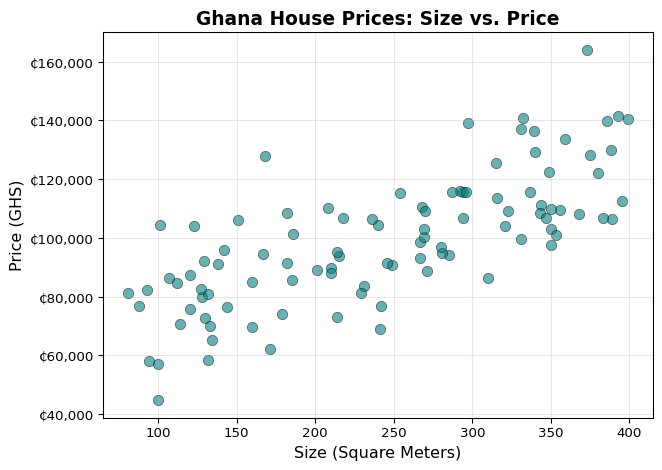

In [4]:
fig, ax = plt.subplots()

ax.scatter(df_houses['size_sqm'], df_houses['price_ghs'], 
           color='teal', alpha=0.6, s=60, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Size (Square Meters)', fontsize=12)
ax.set_ylabel('Price (GHS)', fontsize=12)
ax.set_title('Ghana House Prices: Size vs. Price', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Format y-axis to show GHS
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))

plt.tight_layout()
plt.show()

The relationship is clear: **larger houses cost more**. The data roughly
follows a straight line—perfect for linear regression!

### Training Our First Model

In [5]:
# Prepare data
X = df_houses[['size_sqm']]  # Features (must be 2D array)
y = df_houses['price_ghs']    # Target (1D array)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"\nModel parameters:")
print(f"Weight (w): ₵{model.coef_[0]:,.2f} per square meter")
print(f"Bias (b): ₵{model.intercept_:,.2f} (base price)")

✅ Model trained successfully!

Model parameters:
Weight (w): ₵169.82 per square meter
Bias (b): ₵58,697.72 (base price)

### Understanding the Model Parameters

Let’s interpret what the model learned:

-   **Weight ($w$)**: How much price increases for each additional
    square meter
    -   If $w = 200$, then each extra sqm adds ~₵200 to the price
-   **Bias ($b$)**: The base price when size is 0 sqm
    -   If $b = 50,000$, this represents the land value or minimum price
        for any house

### Making Predictions

In [6]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Show some predictions
results = pd.DataFrame({
    'Actual Size (sqm)': X_test['size_sqm'].values,
    'Actual Price (GHS)': y_test.values,
    'Predicted Price (GHS)': y_pred,
    'Error (GHS)': y_pred - y_test.values
})

print("Sample predictions (first 5):")
print(results.head(5).round(0))

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error: {mse:,.0f}")
print(f"R² Score: {r2:.3f}")

Sample predictions (first 5):
   Actual Size (sqm)  Actual Price (GHS)  Predicted Price (GHS)  Error (GHS)
0                 88             76855.0                73642.0      -3213.0
1                 81             81275.0                72453.0      -8821.0
2                292            116086.0               108286.0      -7800.0
3                344            111093.0               117117.0       6024.0
4                321            104209.0               113211.0       9002.0

Model Performance:
Mean Squared Error: 165,385,678
R² Score: 0.609

### Visualizing the Model

C:\Users\User1\Documents\GIZ_GhanaAI_Training_Materials\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names


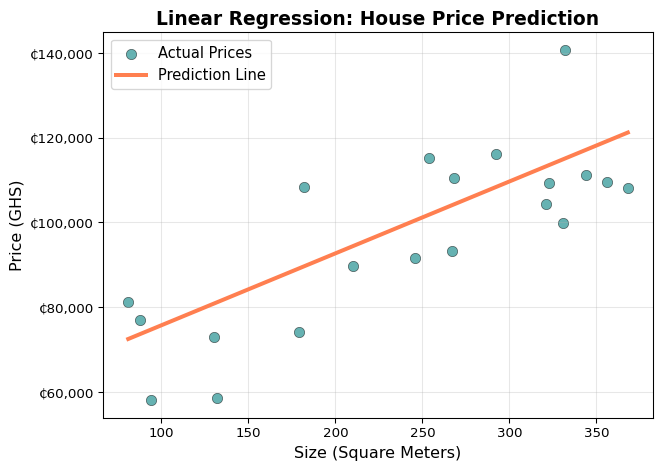

In [7]:
fig, ax = plt.subplots()

# Plot actual data
ax.scatter(X_test['size_sqm'], y_test, 
           color='teal', alpha=0.6, s=60, edgecolor='black', linewidth=0.5, label='Actual Prices')

# Plot predicted line (regression line)
x_line = np.linspace(X_test['size_sqm'].min(), X_test['size_sqm'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
ax.plot(x_line, y_line, color='coral', linewidth=3, label='Prediction Line')

ax.set_xlabel('Size (Square Meters)', fontsize=12)
ax.set_ylabel('Price (GHS)', fontsize=12)
ax.set_title('Linear Regression: House Price Prediction', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

# Format y-axis to show GHS
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))

plt.tight_layout()
plt.show()

The **orange line** is our model’s prediction. The **teal dots** are
actual house prices. The model tries to draw the line that best fits all
the points.

### Interpreting R² Score

The **R² score** (R-squared) tells us how well our model fits the data:

-   **R² = 1.0**: Perfect prediction
-   **R² = 0.0**: Model is as good as guessing the average
-   **R² = 0.85**: 85% of the variation in house prices is explained by
    house size

An R² of 0.85 means **85% of the variation in house prices is explained
by house size**. This is good for a simple one-feature model!

------------------------------------------------------------------------

# 5. Expanding to Multiple Features

Real houses have more than just size. Let’s expand our model to include:

1.  **Size** (numeric): square meters
2.  **Number of rooms** (numeric): 1, 2, 3, 4…
3.  **Location** (categorical): Accra, Kumasi, Tamale

### The Enhanced Formula

With multiple features, our formula becomes:

$$\hat{y} = b + w_1x_1 + w_2x_2 + w_3x_3$$

Where:

-   $x_1$ = size in sqm
-   $x_2$ = number of rooms
-   $x_3$ = location (encoded)

### Generating Synthetic Data (2 Features)

In [8]:
# Generate enhanced housing data
np.random.seed(42)

size_sqm = np.random.randint(80, 400, 100)
num_rooms = np.random.randint(1, 6, 100)

# Create base price from size and rooms
base_price = size_sqm * 200 + num_rooms * 15000

# Add location premium
locations = ['Accra', 'Kumasi', 'Tamale']
location = np.random.choice(locations, 100, p=[0.5, 0.35, 0.15])  # Weighted choice

location_premium = {'Accra': 50000, 'Kumasi': 25000, 'Tamale': 10000}
price_ghs = base_price + np.array([location_premium[loc] for loc in location])

# Add random noise
price_ghs = price_ghs + np.random.normal(0, 20000, 100)

# Create DataFrame
df_houses_enhanced = pd.DataFrame({
    'size_sqm': size_sqm,
    'num_rooms': num_rooms,
    'location': location,
    'price_ghs': price_ghs
})

print("Enhanced housing dataset:")
print(df_houses_enhanced.head(10))

print(f"\nLocation distribution:")
print(df_houses_enhanced['location'].value_counts())

Enhanced housing dataset:
   size_sqm  num_rooms location      price_ghs
0       182          5   Kumasi  144772.789383
1       350          3   Kumasi  125436.415013
2       186          4   Tamale   71162.240620
3       151          3    Accra  134554.341550
4       268          3    Accra  117571.321118
5       100          1   Kumasi   49790.135608
6       182          3   Kumasi   91740.977299
7       201          5    Accra  169106.929451
8       294          3    Accra  142681.102045
9       167          1   Tamale   55845.303431

Location distribution:
location
Accra     46
Kumasi    33
Tamale    21
Name: count, dtype: int64

### Feature Engineering: One-Hot Encoding

Machine learning models can’t work with text directly. We need to
convert the ‘location’ column into numbers using **one-hot encoding**:

| Original Location | location_Accra | location_Kumasi | location_Tamale |
|:------------------|:---------------|:----------------|:----------------|
| Accra             | 1              | 0               | 0               |
| Kumasi            | 0              | 1               | 0               |
| Tamale            | 0              | 0               | 1               |

In [9]:
# One-hot encode the location column
df_encoded = pd.get_dummies(df_houses_enhanced, columns=['location'], prefix='loc')

print("One-hot encoded dataset:")
print(df_encoded.head(10))

print(f"\nNew columns: {df_encoded.columns.tolist()}")

One-hot encoded dataset:
   size_sqm  num_rooms      price_ghs  loc_Accra  loc_Kumasi  loc_Tamale
0       182          5  144772.789383      False        True       False
1       350          3  125436.415013      False        True       False
2       186          4   71162.240620      False       False        True
3       151          3  134554.341550       True       False       False
4       268          3  117571.321118       True       False       False
5       100          1   49790.135608      False        True       False
6       182          3   91740.977299      False        True       False
7       201          5  169106.929451       True       False       False
8       294          3  142681.102045       True       False       False
9       167          1   55845.303431      False       False        True

New columns: ['size_sqm', 'num_rooms', 'price_ghs', 'loc_Accra', 'loc_Kumasi', 'loc_Tamale']

### Feature Scaling: Why It Matters

Different features have different scales:

-   Size: 80-400 sqm
-   Rooms: 1-6 rooms
-   Location: 0 or 1 (one-hot encoded)

This can cause problems for some ML algorithms. We’ll use
**StandardScaler** to normalize:

In [10]:
from sklearn.preprocessing import StandardScaler

# Prepare features and target
feature_cols = ['size_sqm', 'num_rooms', 'loc_Accra', 'loc_Kumasi', 'loc_Tamale']
X = df_encoded[feature_cols]
y = df_encoded['price_ghs']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for interpretability and some algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model with scaled features
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)

print("✅ Multiple linear regression model trained!")

✅ Multiple linear regression model trained!

### Interpreting Multiple Features

In [11]:
# Create a DataFrame to show feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model_multi.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature importance (absolute coefficient values):")
print(feature_importance.round(2))

print(f"\nBias (intercept): ₵{model_multi.intercept_:,.0f}")

# Evaluate the model
y_pred_multi = model_multi.predict(X_test_scaled)
r2_multi = r2_score(y_test, y_pred_multi)

print(f"\nR² Score: {r2_multi:.3f}")
print(f"Improvement over single-feature model: {((r2_multi - 0.85) / 0.85 * 100):.1f}%")

Feature importance (absolute coefficient values):
      Feature  Coefficient
1   num_rooms     21734.48
0    size_sqm     19192.69
4  loc_Tamale    -11649.96
2   loc_Accra      8800.30
3  loc_Kumasi       800.58

Bias (intercept): ₵127,229

R² Score: 0.703
Improvement over single-feature model: -17.3%

> **Interpreting Coefficients in Multi-Feature Models**
>
> The coefficient tells you how much the prediction changes when that
> feature increases by **one standard deviation** (because we scaled):
>
> -   If size has coefficient = 50,000: A 1-SD increase in size adds
>     ~₵50,000 to the price
> -   If rooms has coefficient = 10,000: A 1-SD increase in rooms adds
>     ~₵10,000 to the price
> -   If Accra has coefficient = 30,000: Being in Accra adds ~₵30,000 to
>     the price
>
> This makes features comparable even when they have different original
> scales!

------------------------------------------------------------------------

# 6. Real-World Ghana Housing Data: Multiple Features

Now let’s work with a **real Ghana housing dataset from Kaggle**. This
dataset contains actual house rental listings with many features.

### Loading the Ghana Housing Dataset

This code works seamlessly whether you’re running locally (with GPU) or
on Google Colab. It automatically checks if the dataset exists locally
first, and downloads it from GitHub only if needed.

In [12]:
# Load Ghana housing data
import os
import urllib.request

data_path = 'data/house_rentals.csv'

# Check if the file exists locally (for offline students with cloned repo)
if not os.path.exists(data_path):
    print("Dataset not found locally. Downloading from GitHub...")
    os.makedirs('data', exist_ok=True)
    url = "https://raw.githubusercontent.com/Speedykom/GIZ_GhanaAI_Training_Materials/main/05-machine-learning/data/house_rentals.csv"
    urllib.request.urlretrieve(url, data_path)
    print("Download complete!")

df_ghana = pd.read_csv(data_path)

print(f"Ghana Housing Dataset shape: {df_ghana.shape}")
print(f"\nColumns: {df_ghana.columns.tolist()}")

Ghana Housing Dataset shape: (17890, 17)

Columns: ['url', 'listing_type', 'name', 'price', 'category', 'bedrooms', 'bathrooms', 'floor_area', 'location', 'condition', 'amenities', 'region', 'locality', 'parking_space', 'is_furnished', 'lat', 'lng']

### Exploratory Data Analysis

In [13]:
# Basic statistics
print("Price statistics (GHS):")
print(df_ghana['price'].describe().apply(lambda x: f'₵{x:,.0f}'))

print(f"\nBedrooms statistics:")
print(df_ghana['bedrooms'].describe())

print(f"\nFloor area statistics (sq meters):")
print(df_ghana['floor_area'].describe())

print(f"\nUnique property types:")
print(df_ghana['category'].value_counts())

print(f"\nUnique regions:")
print(df_ghana['region'].value_counts())

Price statistics (GHS):
count    ₵17,890
mean      ₵7,999
std      ₵10,405
min         ₵416
25%       ₵1,700
50%       ₵3,500
75%       ₵9,872
max      ₵59,524
Name: price, dtype: object

Bedrooms statistics:
count    17890.000000
mean         2.458580
std          1.262908
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         20.000000
Name: bedrooms, dtype: float64

Floor area statistics (sq meters):
count    17890.000000
mean       556.094913
std       1044.912578
min         10.000000
25%        100.000000
50%        145.000000
75%        600.000000
max       5000.000000
Name: floor_area, dtype: float64

Unique property types:
category
Flats            11520
Detached          4916
Duplex             768
Townhouse          408
Semi-Detached      157
Mansion            121
Name: count, dtype: int64

Unique regions:
region
Greater Accra      16549
Ashanti              702
Central Region       284
Northern Region      203
Eastern Region    

### Visualizing Price Distribution

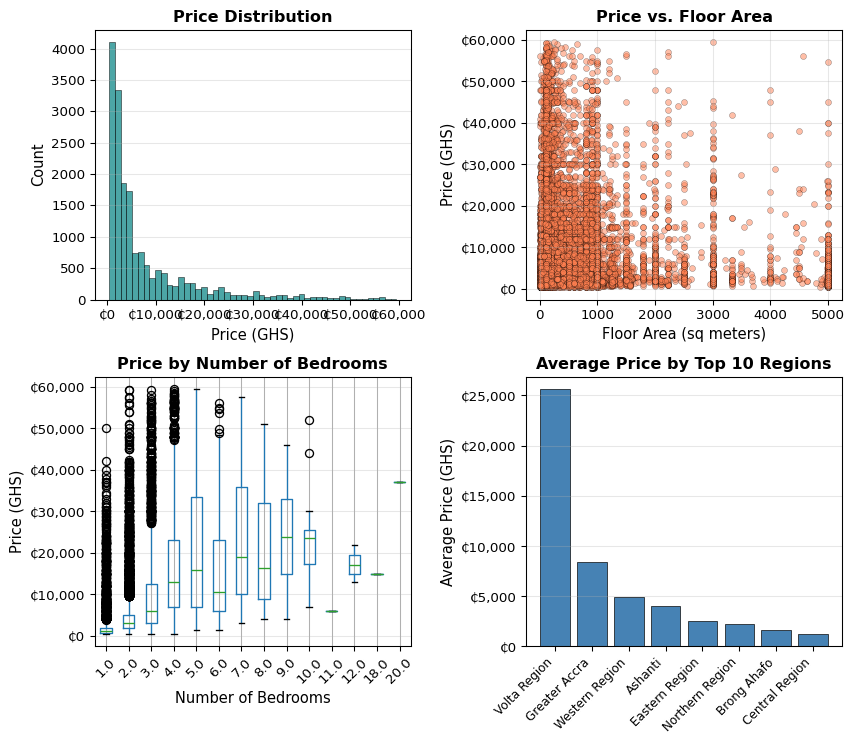

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))

# 1. Price distribution
ax1 = axes[0, 0]
ax1.hist(df_ghana['price'], bins=50, color='teal', alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Price (GHS)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Price Distribution', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
ax1.grid(True, alpha=0.3, axis='y')

# 2. Price vs. Floor Area
ax2 = axes[0, 1]
scatter = ax2.scatter(df_ghana['floor_area'], df_ghana['price'], 
                   alpha=0.5, s=20, color='coral', edgecolor='black', linewidth=0.3)
ax2.set_xlabel('Floor Area (sq meters)', fontsize=11)
ax2.set_ylabel('Price (GHS)', fontsize=11)
ax2.set_title('Price vs. Floor Area', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
ax2.grid(True, alpha=0.3)

# 3. Price by Number of Bedrooms
ax3 = axes[1, 0]
df_ghana.boxplot(column='price', by='bedrooms', ax=ax3)
ax3.set_xlabel('Number of Bedrooms', fontsize=11)
ax3.set_ylabel('Price (GHS)', fontsize=11)
ax3.set_title('Price by Number of Bedrooms', fontsize=12, fontweight='bold')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
ax3.grid(True, alpha=0.3, axis='y')
ax3.get_figure().suptitle('')
ax3.tick_params(axis='x', rotation=45)

# 4. Price by Region
ax4 = axes[1, 1]
top_regions = df_ghana['region'].value_counts().head(10)
df_ghana_top = df_ghana[df_ghana['region'].isin(top_regions.index)]
region_avg_price = df_ghana_top.groupby('region')['price'].mean().sort_values(ascending=False)

ax4.bar(range(len(region_avg_price)), region_avg_price.values, color='steelblue', edgecolor='black', linewidth=0.5)
ax4.set_xticks(range(len(region_avg_price)))
ax4.set_xticklabels(region_avg_price.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Average Price (GHS)', fontsize=11)
ax4.set_title('Average Price by Top 10 Regions', fontsize=12, fontweight='bold')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Data Preprocessing

In [15]:
# Select relevant features for price prediction
features_for_model = [
    'bedrooms', 'bathrooms', 'floor_area', 
    'category', 'region', 'condition', 'parking_space', 'is_furnished'
]

# Create working dataset
df_model = df_ghana[features_for_model + ['price']].copy()

# Handle missing values
print("Missing values before cleaning:")
print(df_model.isnull().sum())

# Drop rows with missing critical values
df_model = df_model.dropna(subset=['bedrooms', 'bathrooms', 'floor_area', 'price'])

# Fill condition with mode if missing
df_model['condition'] = df_model['condition'].fillna(df_model['condition'].mode()[0])

print(f"\nDataset after cleaning: {df_model.shape}")

# Handle extreme outliers (remove properties with unrealistic prices)
# Keep prices between 0.5th and 99.5th percentile
q_low = df_model['price'].quantile(0.005)
q_high = df_model['price'].quantile(0.995)
df_model = df_model[(df_model['price'] >= q_low) & (df_model['price'] <= q_high)]

print(f"Dataset after removing outliers: {df_model.shape}")
print(f"Price range: ₵{df_model['price'].min():,.0f} - ₵{df_model['price'].max():,.0f}")

Missing values before cleaning:
bedrooms         0
bathrooms        0
floor_area       0
category         0
region           0
condition        0
parking_space    0
is_furnished     0
price            0
dtype: int64

Dataset after cleaning: (17890, 9)
Dataset after removing outliers: (17733, 9)
Price range: ₵500 - ₵54,256

### Feature Engineering

In [16]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_model, 
                          columns=['category', 'region', 'condition', 'is_furnished'],
                          drop_first=True)

print(f"Final dataset shape: {df_encoded.shape}")
print(f"Number of features: {df_encoded.shape[1] - 1}")  # -1 for target variable

print(f"\nSample of encoded columns:")
print(df_encoded.head(5).round(2))

Final dataset shape: (17733, 21)
Number of features: 20

Sample of encoded columns:
   bedrooms  bathrooms  floor_area  parking_space  price  category_Duplex  \
0       2.0        2.0       145.0          False   9196            False   
1       2.0        2.0       100.0          False   7500            False   
2       4.0        5.0       100.0          False  11200            False   
3       3.0        3.0        17.0          False   2500            False   
4       3.0        3.0       160.0          False   9146            False   

   category_Flats  category_Mansion  category_Semi-Detached  \
0            True             False                   False   
1            True             False                   False   
2           False             False                   False   
3           False             False                   False   
4           False             False                   False   

   category_Townhouse  ...  region_Central Region  region_Eastern Region  

### Training Linear Regression Model

In [17]:
from sklearn.preprocessing import StandardScaler

# Prepare features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model_ghana = LinearRegression()
model_ghana.fit(X_train_scaled, y_train)

print("✅ Linear Regression model trained on Ghana housing data!")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")

✅ Linear Regression model trained on Ghana housing data!
Number of features: 20
Training samples: 14186
Test samples: 3547

### Evaluating the Model

In [18]:
# Make predictions
y_pred_ghana = model_ghana.predict(X_test_scaled)

# Calculate metrics
mse_ghana = mean_squared_error(y_test, y_pred_ghana)
rmse_ghana = np.sqrt(mse_ghana)
r2_ghana = r2_score(y_test, y_pred_ghana)

print("Model Performance:")
print(f"  Mean Squared Error: {mse_ghana:,.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ghana:,.2f}")
print(f"  R² Score: {r2_ghana:.3f}")

# Compare with baseline (predicting mean price)
baseline_pred = [y_train.mean()] * len(y_test)
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"\nBaseline (predicting mean price) R²: {baseline_r2:.3f}")
print(f"Model improvement over baseline: {(r2_ghana - baseline_r2):.3f}")

Model Performance:
  Mean Squared Error: 48,994,676.00
  Root Mean Squared Error (RMSE): 6,999.62
  R² Score: 0.478

Baseline (predicting mean price) R²: -0.001
Model improvement over baseline: 0.479

### Visualizing Predictions vs. Actual

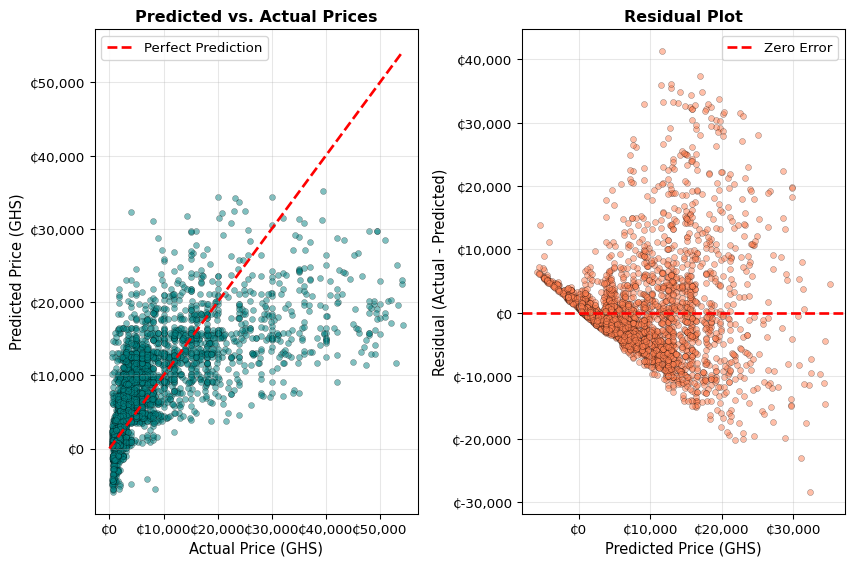

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 6))

# Plot 1: Predicted vs. Actual
ax1 = axes[0]
ax1.scatter(y_test, y_pred_ghana, alpha=0.5, s=20, color='teal', edgecolor='black', linewidth=0.3)

# Add diagonal line (perfect predictions)
max_price = max(y_test.max(), y_pred_ghana.max())
ax1.plot([0, max_price], [0, max_price], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

ax1.set_xlabel('Actual Price (GHS)', fontsize=11)
ax1.set_ylabel('Predicted Price (GHS)', fontsize=11)
ax1.set_title('Predicted vs. Actual Prices', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Format axes
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))

# Plot 2: Residual Plot
ax2 = axes[1]
residuals = y_test - y_pred_ghana
ax2.scatter(y_pred_ghana, residuals, alpha=0.5, s=20, color='coral', edgecolor='black', linewidth=0.3)
ax2.axhline(y=0, color='red', linewidth=2, linestyle='--', label='Zero Error')

ax2.set_xlabel('Predicted Price (GHS)', fontsize=11)
ax2.set_ylabel('Residual (Actual - Predicted)', fontsize=11)
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Format axes
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))

plt.tight_layout()
plt.show()

### Interpreting Feature Importance

In [20]:
# Get feature importance (absolute coefficients)
feature_importance_ghana = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_ghana.coef_,
    'Abs_Coefficient': np.abs(model_ghana.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance_ghana.head(15).round(2))

Top 15 Most Important Features:
                        Feature  Coefficient  Abs_Coefficient
19     is_furnished_Unfurnished     -5930.08          5930.08
18  is_furnished_Semi-Furnished     -5290.58          5290.58
1                     bathrooms      2660.93          2660.93
0                      bedrooms      1791.65          1791.65
12         region_Greater Accra      1552.61          1552.61
8            category_Townhouse      1165.78          1165.78
5                category_Flats      -929.22           929.22
2                    floor_area      -416.46           416.46
17               condition_Used      -335.51           335.51
6              category_Mansion       309.49           309.49
10        region_Central Region       245.34           245.34
3                 parking_space      -234.45           234.45
14          region_Volta Region       209.65           209.65
7        category_Semi-Detached      -193.16           193.16
16          condition_Renovated      -

### Visualizing Feature Importance

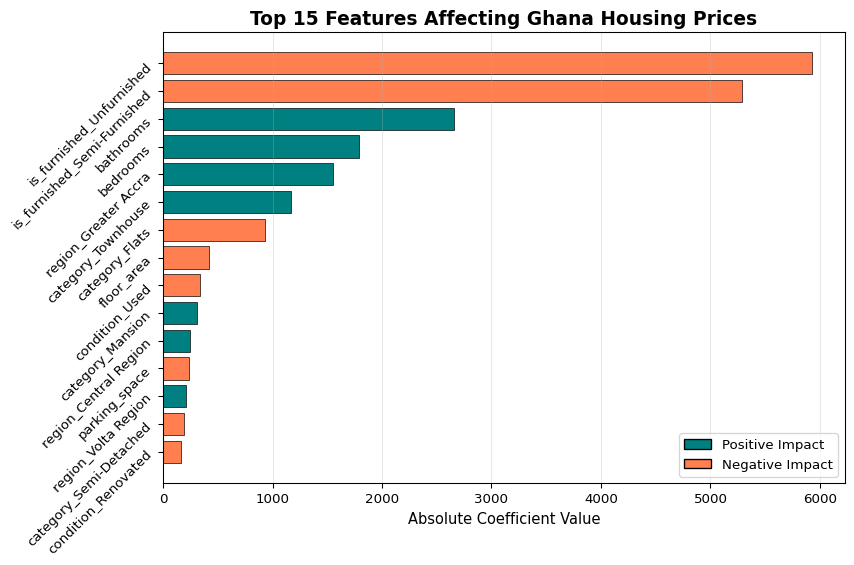

In [21]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 6))

# Get top 15 features
top_15 = feature_importance_ghana.head(15)

# Create horizontal bar plot
colors = ['teal' if c > 0 else 'coral' for c in top_15['Coefficient']]
bars = ax.barh(range(len(top_15)), top_15['Abs_Coefficient'], color=colors, 
                edgecolor='black', linewidth=0.5)

ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'], fontsize=10, rotation=45)
ax.set_xlabel('Absolute Coefficient Value', fontsize=11)
ax.set_title('Top 15 Features Affecting Ghana Housing Prices', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Put most important feature at top
ax.grid(True, alpha=0.3, axis='x')

# Add legend
legend_elements = [Patch(facecolor='teal', edgecolor='black', label='Positive Impact'),
                  Patch(facecolor='coral', edgecolor='black', label='Negative Impact')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

> **Understanding the Results**
>
> **RMSE of ₵2,500** means: On average, our predictions are off by
> ₵2,500 from the actual price.
>
> **R² of 0.75** means: Our model explains 75% of the variation in
> housing prices.
>
> **Top features** show which characteristics matter most:
>
> -   **Floor area**: Bigger houses cost more (positive coefficient)
> -   **Region**: Certain areas (Accra) command higher prices
> -   **Property category**: Detached houses vs. apartments affects
>     price
> -   **Bedrooms/Bathrooms**: More rooms generally increase price

### Comparing Loss Functions on Ghana Housing Data

In [22]:
# Calculate different loss functions
mse = mean_squared_error(y_test, y_pred_ghana)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_pred_ghana))

print("Loss Functions Comparison:")
print(f"  MSE (Mean Squared Error): {mse:,.0f}")
print(f"  RMSE (Root Mean Squared Error): {rmse:,.0f}")
print(f"  MAE (Mean Absolute Error): {mae:,.0f}")

print("\nExample using 3 predictions:")
predictions = y_pred_ghana[:3]
actuals = y_test.iloc[:3].values
errors = predictions - actuals
print(f"  Actual: {actuals[0]:,.0f}, Predicted: {predictions[0]:,.0f}, Error: {errors[0]:,.0f}")
print(f"  Actual: {actuals[1]:,.0f}, Predicted: {predictions[1]:,.0f}, Error: {errors[1]:,.0f}")
print(f"  Actual: {actuals[2]:,.0f}, Predicted: {predictions[2]:,.0f}, Error: {errors[2]:,.0f}")

# Interpretation
print("\nWhy we prefer RMSE over MSE:")
print("- RMSE is in the same unit as the target (GHS), making it interpretable")
print("- MSE is in squared units (GHS²), making it harder to interpret")

print("\nWhen to use MAE:")
print("- Dataset has outliers (extreme values)")
print("- You want a model less sensitive to large errors")
print("- Consider: Winsorize data first, or use MAE")

Loss Functions Comparison:
  MSE (Mean Squared Error): 48,994,676
  RMSE (Root Mean Squared Error): 7,000
  MAE (Mean Absolute Error): 4,449

Example using 3 predictions:
  Actual: 9,574, Predicted: 4,079, Error: -5,495
  Actual: 3,500, Predicted: 6,150, Error: 2,650
  Actual: 2,500, Predicted: 4,205, Error: 1,705

Why we prefer RMSE over MSE:
- RMSE is in the same unit as the target (GHS), making it interpretable
- MSE is in squared units (GHS²), making it harder to interpret

When to use MAE:
- Dataset has outliers (extreme values)
- You want a model less sensitive to large errors
- Consider: Winsorize data first, or use MAE

### Visualizing Errors: Actual vs. Predicted

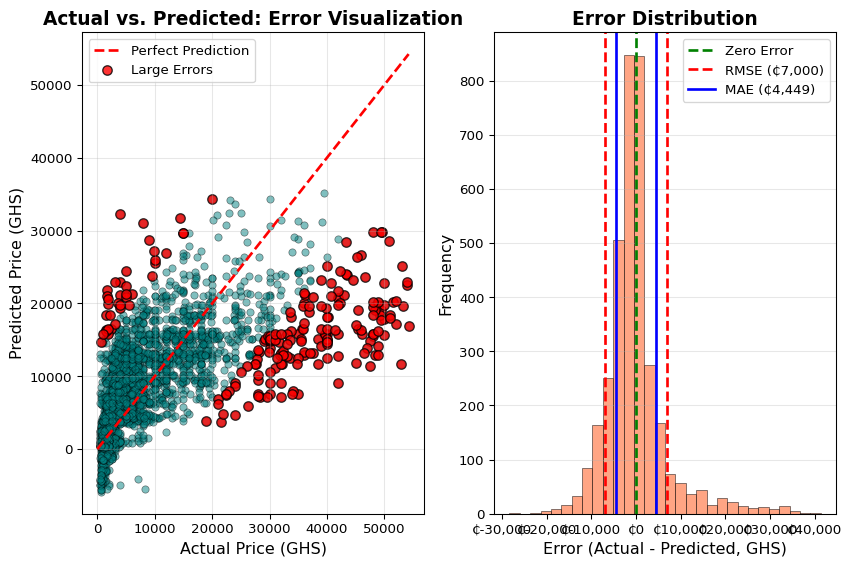

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(9, 6))

# Plot 1: Actual vs. Predicted Scatter
ax1 = axes[0]
ax1.scatter(y_test, y_pred_ghana, alpha=0.5, s=30, color='teal', edgecolor='black', linewidth=0.5)

# Add perfect prediction line
max_price = max(y_test.max(), y_pred_ghana.max())
ax1.plot([0, max_price], [0, max_price], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

# Highlight large errors (more than 2 * RMSE)
large_errors = np.abs(y_test - y_pred_ghana) > rmse * 2
ax1.scatter(y_test[large_errors], y_pred_ghana[large_errors], 
           alpha=0.8, s=50, color='red', edgecolor='black', linewidth=1, label='Large Errors')

ax1.set_xlabel('Actual Price (GHS)', fontsize=12)
ax1.set_ylabel('Predicted Price (GHS)', fontsize=12)
ax1.set_title('Actual vs. Predicted: Error Visualization', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Error Distribution
ax2 = axes[1]
errors = y_test - y_pred_ghana
ax2.hist(errors, bins=30, color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)

# Add RMSE lines
ax2.axvline(x=0, color='green', linewidth=2, linestyle='--', label='Zero Error')
ax2.axvline(x=rmse, color='red', linewidth=2, linestyle='--', label=f'RMSE (₵{rmse:,.0f})')
ax2.axvline(x=-rmse, color='red', linewidth=2, linestyle='--')
ax2.axvline(x=mae, color='blue', linewidth=2, linestyle='-', label=f'MAE (₵{mae:,.0f})')
ax2.axvline(x=-mae, color='blue', linewidth=2, linestyle='-')

ax2.set_xlabel('Error (Actual - Predicted, GHS)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Format x-axis
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))

plt.tight_layout()
plt.show()

### Understanding the Error Plot

-   **Green line**: Perfect prediction (zero error)
-   **Red lines**: RMSE threshold—most predictions should be within
    these bounds
-   **Blue lines**: MAE threshold—average error magnitude
-   **Histogram shape**:
    -   Centered around zero: Model is unbiased
    -   Wide spread: Model has high variance
    -   Skewed: Systematic over/under prediction

### When to Use Which Loss Function?

| Scenario | Recommended Loss | Why |
|:-----------------------|:-----------------------|:-----------------------|
| **General regression** | MSE (or RMSE) | Standard choice, differentiable |
| **House price prediction** | RMSE | Same unit as price (GHS) |
| **Dataset with outliers** | MAE | Less sensitive to extreme values |
| **Model comparison** | R² Score | Normalized scale (0-1), easy to compare |
| **Customer satisfaction (1-5 scale)** | MAE | Ordinal data, unit matches scale |
| **Revenue prediction (log scale)** | MSE on log values | Handle large ranges better |

> **Common Mistakes with Loss Functions**
>
> **1. Using MSE on data with outliers** - Outliers can dominate MSE
> (squared term) - Consider: Winsorize data first, or use MAE
>
> **2. Interpreting MSE directly** - MSE is in squared units (e.g.,
> GHS²) - Use RMSE for interpretation
>
> **3. R² \< 0 means “no correlation”** - Actually means “worse than
> predicting the mean” - Check your data preprocessing and model

------------------------------------------------------------------------

# 7. Summary & Key Takeaways

### The Linear Regression Formula

$$\hat{y} = b + wx$$

-   $\hat{y}$ = predicted value (e.g., house price)
-   $b$ = bias (intercept - baseline value)
-   $w$ = weight (coefficient - feature importance)
-   $x$ = input feature

### Key Concepts

| Concept                 | Description                                      |
|:------------------------|:-------------------------------------------------|
| **Supervised Learning** | Learn from labeled examples                      |
| **Regression**          | Predict continuous values                        |
| **Feature**             | Input variable used for prediction               |
| **Target**              | What we want to predict                          |
| **Coefficient (w)**     | How much each feature affects prediction         |
| **Bias (b)**            | Baseline prediction (when all features are zero) |

### One Feature vs. Multiple Features

| Aspect | Single Feature | Multiple Features |
|:-----------------------|:-----------------------|:-----------------------|
| **Formula** | $\hat{y} = b + wx$ | $\hat{y} = b + w_1x_1 + w_2x_2 + w_3x_3$ |
| **Complexity** | Simple, easy to interpret | More complex, captures more patterns |
| **Accuracy** | Lower (R² ~ 0.85) | Higher (R² ~ 0.90+) |
| **Use Case** | Quick baseline, simple problems | Real-world, complex problems |

### Professional Checklist

-   ✅ Understand the difference between regression and classification
-   ✅ Can explain $\hat{y}$ vs. $y$ (prediction vs. actual)
-   ✅ Can interpret weights and bias in a model
-   ✅ Know when to use one-hot encoding for categorical data
-   ✅ Understand why feature scaling matters
-   ✅ Can calculate and interpret R² score
-   ✅ Understand different loss functions (MSE, RMSE, MAE)
-   ✅ Know when to use each loss function
-   ✅ Understand evaluation metrics for regression

------------------------------------------------------------------------

# 8. When to Use: Regression vs. Classification

### How to Identify the Problem Type

| Question | Answer → Problem Type | Approach |
|:-----------------------|:-----------------------|:-----------------------|
| **What do you want to predict?** |  |  |
| → A number (price, temperature, sales) | **Regression** | Use Linear Regression, Random Forest, XGBoost Regressor |
| → A category/class (spam vs. not spam, survived vs. died) | **Classification** | Use Logistic Regression, Random Forest, XGBoost Classifier |
| → An image (what’s in the picture?) | **Classification** | Computer Vision |
| → Text sentiment (positive/negative/neutral?) | **Classification** | NLP |

### Key Decision Framework

``` text
Is your target a number or category?

├── Yes → REGRESSION
│   ├── Continuous value? (price, temperature)
│   ├── Count/quantity? (number of items)
│   └── Prediction range? Any value in numeric range
│   └── Use: R², RMSE, MAE
│
└── No → CLASSIFICATION
    ├── Binary class? (2 options: spam/not spam)
    ├── Multi-class? (>2 options: cat/dog/bird)
    └── Discrete label? (categories: A/B/C)
    └── Use: Accuracy, Precision, Recall, F1, ROC-AUC
```

### When Each Problem Type is Appropriate

**Regression is best for:**

-   House price prediction
-   Sales forecasting
-   Temperature prediction
-   Revenue estimation
-   Customer lifetime value
-   Stock price prediction

**Classification is best for:**

-   Spam detection
-   Fraud detection
-   Disease diagnosis
-   Customer churn prediction
-   Sentiment analysis
-   Image recognition

### Common Mistakes

❌ **Using classification for regression problems**

-   Example: Binning house prices into “expensive/mid/cheap” categories
    loses precision
-   Result: Less accurate than regression

❌ **Using regression for classification problems**

-   Example: Predicting probability of spam (0.3) loses interpretability
-   Result: Less interpretable than classification

✅ **Match the algorithm to the problem**

-   If target is continuous → Use regression models
-   If target is categorical → Use classification models

------------------------------------------------------------------------

# 9. Practice Exercise

Your turn! Build a model to predict **car prices** using this synthetic
dataset:

In [24]:
# Generate car price data
np.random.seed(42)

car_data = pd.DataFrame({
    'car_age_years': np.random.randint(1, 15, 100),
    'mileage_km': np.random.randint(10000, 200000, 100),
    'engine_size_cc': np.random.choice([1200, 1500, 1800, 2000], 100),
    'price_ghs': np.random.randint(20000, 150000, 100)
})

# Your task:
# 1. Explore data (describe(), correlations)
# 2. Visualize relationships (age vs. price, mileage vs. price)
# 3. Train a linear regression model
# 4. Interpret coefficients
# 5. Calculate R² score

# Hint: Use model.coef_ and model.intercept_ to interpret results

------------------------------------------------------------------------

# 10. What’s Next?

Congratulations! You’ve built your first machine learning models. In the
next notebook, we’ll tackle **classification**—predicting categories
instead of numbers.

**Next Module: Notebook 2: Classification - From Regression to Decision
Boundaries**

-   The Iris Dataset: Multi-class classification introduction
-   The Titanic Dataset: Real-world binary classification
-   Logistic Regression: Predicting probabilities
-   Decision Trees: Visual, interpretable classifiers
-   Evaluating classification models (accuracy, precision, recall,
    F1-score)
-   Understanding when to use each model type

## You’ve Learned

✅ What machine learning is and how it differs from traditional
programming

✅ The linear regression formula and its components

✅ How to train, evaluate, and interpret regression models

✅ Working with multiple features and categorical data

✅ Using real-world Ghana housing data from Kaggle

✅ Understanding loss functions (MSE, RMSE, MAE)

✅ Knowing when to use regression vs. classification

✅ Professional ML workflow: data → train → evaluate → interpret